In [20]:
%load_ext autoreload
%autoreload 2

In [30]:
import load_data
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown
from IPython.display import display, Markdown, Math
import numpy as np

In [36]:
load_data.reload()

funnel table loaded!
duration table loaded!
transition table loaded!
completion time table loaded!
all tables reloaded!


In [37]:
df_duration = load_data.load("duration")
df_funnel = load_data.load("funnel")
df_duration.head()

duration table loaded!
funnel table loaded!


,client_id,variation,process_step,date_time,duration_sec
0,555,Test,start,2017-04-15 12:57:56+00:00,7.0
1,555,Test,step_1,2017-04-15 12:58:03+00:00,32.0
2,555,Test,step_2,2017-04-15 12:58:35+00:00,99.0
3,555,Test,step_3,2017-04-15 13:00:14+00:00,20.0
4,555,Test,confirm,2017-04-15 13:00:34+00:00,NaN


In [38]:
completed_clients = df_funnel[
    (df_funnel['start'] == 1) &
    (df_funnel['confirm'] == 1)
][['client_id','variation']]
completed_clients

,client_id,variation
0,555,Test
1,647,Test
6,1195,Control
7,1197,Control
8,1336,Test
...,...,...
50491,9998851,Test
50493,9998964,Test
50494,9999009,Test
50496,9999400,Test


In [44]:
df_completion_time = load_data.load("completion_time")
df_completion_time_test = df_completion_time[df_completion_time.variation == "Test"]
df_completion_time_control = df_completion_time[df_completion_time.variation == "Control"]

csv doesn't exist, loading from database...
completion time table loaded!


52 completed clients (0.15%) were excluded from completion-time analysis because their earliest confirm event occurred before their earliest recorded start event, making completion duration undefined.

In [45]:
display(df_completion_time.describe())
display(df_completion_time_test.describe())
display(df_completion_time_control.describe())

,client_id,calendar_completion_time_sec,active_completion_time_sec
count,33706.0,33706.0,33706.0
mean,5004472.433306,271579.028215,417.439833
std,2871813.033856,936242.84709,479.031132
min,555.0,32.0,0.0
25%,2518759.0,173.0,163.0
50%,5036812.0,300.0,268.0
75%,7465140.0,711.0,478.0
max,9999729.0,8373894.0,8148.0


,client_id,calendar_completion_time_sec,active_completion_time_sec
count,18403.0,18403.0,18403.0
mean,4986264.753029,231669.24007,415.083247
std,2873177.904068,847411.008713,502.455362
min,555.0,32.0,0.0
25%,2495753.5,160.0,152.0
50%,5032714.0,281.0,254.0
75%,7425334.5,667.5,471.0
max,9999729.0,7810368.0,8148.0


,client_id,calendar_completion_time_sec,active_completion_time_sec
count,15303.0,15303.0,15303.0
mean,5026368.528197,319573.528066,420.273803
std,2870111.705991,1030986.46709,449.247076
min,1195.0,33.0,0.0
25%,2549167.0,191.0,178.0
50%,5040733.0,322.0,282.0
75%,7495186.5,756.0,485.0
max,9998346.0,8373894.0,7755.0


In [48]:
df_duration['duration_sec'].quantile(
    [0.90,0.95,0.99,0.995,0.999]
)

0.900     177.000
0.950     299.000
0.990     962.000
0.995    1059.065
0.999    2017.278
Name: duration_sec, dtype: float64

In [49]:
from scipy.stats import mannwhitneyu

u_stat, p_value = mannwhitneyu(
    df_completion_time_test['active_completion_time_sec'],
    df_completion_time_control['active_completion_time_sec'],
    alternative='two-sided'
)
p_value

np.float64(6.450318205084756e-32)

In [50]:
from scipy.stats import ttest_ind

t_stat, p_value = ttest_ind(
    df_completion_time_test['active_completion_time_sec'],
    df_completion_time_control['active_completion_time_sec'],
    equal_var=False
)
p_value

np.float64(0.31700392950245715)

In [51]:
df_completion_time.groupby(
    'variation'
)['active_completion_time_sec'].quantile(
    [0.5,0.9,0.95,0.99]
)

variation      
Control    0.50      282.0
           0.90      853.8
           0.95     1201.0
           0.99    2211.82
Test       0.50      254.0
           0.90      892.0
           0.95     1292.6
           0.99    2466.94
Name: active_completion_time_sec, dtype: Float64

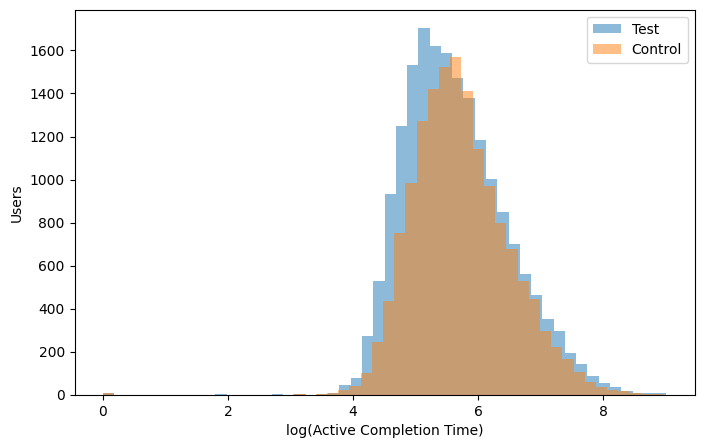

In [52]:
plt.figure(figsize=(8,5))

plt.hist(
    np.log1p(
        df_completion_time_test['active_completion_time_sec']
    ),
    bins=50,
    alpha=0.5,
    label='Test'
)

plt.hist(
    np.log1p(
        df_completion_time_control['active_completion_time_sec']
    ),
    bins=50,
    alpha=0.5,
    label='Control'
)

plt.legend()
plt.xlabel('log(Active Completion Time)')
plt.ylabel('Users')
plt.show()

In [53]:
df_duration.groupby(
    ['variation','process_step']
)['duration_sec'].median()

variation  process_step
Control    confirm         50.0
           start           20.0
           step_1          20.0
           step_2          64.0
           step_3          72.0
Test       confirm         93.0
           start           14.0
           step_1          27.0
           step_2          61.0
           step_3          58.0
Name: duration_sec, dtype: float64

In [54]:
df_duration.groupby(
    ['variation','process_step']
)['duration_sec'].mean()

variation  process_step
Control    confirm         178.100109
           start            66.826566
           step_1           50.464214
           step_2           91.787145
           step_3          136.715226
Test       confirm         244.478048
           start            61.470102
           step_1           60.622449
           step_2           88.848872
           step_3          129.646662
Name: duration_sec, dtype: float64